# Tests Conv Deconv (2b)

- creation: *17/02/2025*

Pour comparer avec (2a) qui sert de référence, en modifiant des paramètres.

## Modules

In [1]:
import os
import torch
import torch.nn as nn
import torchvision
from torchvision import transforms as T
from torchvision.io import read_image, decode_image
from PIL import ImageDraw


In [2]:
print(torchvision.__version__)

0.20.1


In [3]:
from datasets import DATASET_0, DATASET_2
from utils import display_image_tensor as display_image_tensor_, display_pictures_grid, to_0_255, unnormalize
from utils import alexnetfordeconv, clean_feature_maps, deconvolution, get_output_sizes, get_receptive_field_in_pixel_space


In [4]:
# Spécifiquement pour un carnet de type Jupyter
def display_image_tensor(img_tensor, verbose=True):
    if display:
        display_image_tensor_(img_tensor, verbose=verbose, fn_display=display)

## Devices

In [5]:
device = (
    "cuda"
    if torch.cuda.is_available()
    else "mps"
    if torch.backends.mps.is_available()
    else "cpu"
)
print(f"Using {device} device")

Using mps device


## Paramètres modifiés

In [ ]:
ImageFile = "n04037443_racer.JPEG" #"n02391049_zebra.JPEG"
idx_layer = 5 # 2, 5, (7), (9), 14 // [1, 2, 3, 4, 5] # layer in article compliancy with alexnet
flip_kernels = False
use_bias = False
lcn_kernel_size = 5

## Chargement d'une image particulière

In [7]:
DataPath = DATASET_2["path"] #DATASET_2["mounted_path"]
#ImageFile = "n02391049_zebra.JPEG"
filename = os.path.join(DataPath, ImageFile)
(left, top), (right, bottom) = (325, 150), (365, 190) # zone entourant l'oeil du zèbre

Dimensions torch.Size([3, 333, 500]) 
Valeur min: 0 
Valeur max: 255


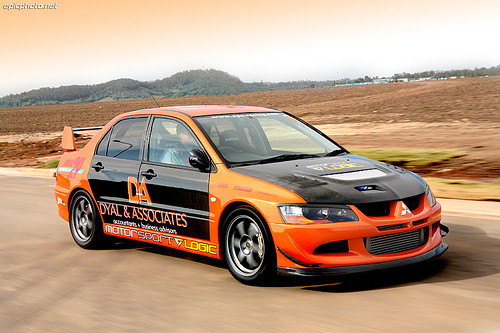

In [8]:
img1_t = decode_image(filename)
#img1_t = read_image(filename)
display_image_tensor(img1_t)

### Manipulations

Dimensions torch.Size([3, 40, 40]) 
Valeur min: 0 
Valeur max: 255


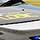

In [9]:
# Tensor space
crop_t = img1_t[:, top:bottom, left:right] # (C, H, W)
# PIL space
display_image_tensor(crop_t)

In [10]:
imagenet_mean = DATASET_0["means"] # Car utilisation des poids de imagenet-1K
imagenet_std = DATASET_0["stds"] # Car utilisation des poids de imagenet-1K

geometry_transforms = T.Compose([
    T.Resize(256),
    T.CenterCrop(224),
])

transforms = T.Compose([
    geometry_transforms,
    T.Lambda(lambda t: t/255.), # because read_image -> [0..255]
    T.Normalize(mean=imagenet_mean, std=imagenet_std),
])

Affichage de l'image après transformations géométriques appliquées.

Dimensions torch.Size([3, 224, 224]) 
Valeur min: 0 
Valeur max: 255


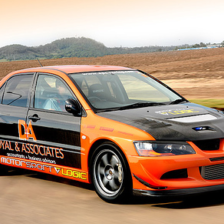

In [11]:
img_tensor_tfd_geo = geometry_transforms(img1_t)
display_image_tensor(img_tensor_tfd_geo)

Affichage de l'image après toutes les transformations.

Dimensions torch.Size([3, 224, 224]) 
Valeur min: -2.1179039478302 
Valeur max: 2.640000104904175


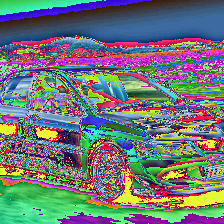

In [12]:
img_tensor_tfd = transforms(img1_t)
display_image_tensor(img_tensor_tfd)

Création d'un batch pour le test.

In [13]:
batch_input = img_tensor_tfd.unsqueeze(dim=0)

## Chargement d'Alexnet et propagation (inférence) dans la partie "features" du modèle

### Chargement

In [14]:
model_alexnet = torchvision.models.alexnet(weights='IMAGENET1K_V1')
model_alexnet.eval()

AlexNet(
  (features): Sequential(
    (0): Conv2d(3, 64, kernel_size=(11, 11), stride=(4, 4), padding=(2, 2))
    (1): ReLU(inplace=True)
    (2): MaxPool2d(kernel_size=3, stride=2, padding=0, dilation=1, ceil_mode=False)
    (3): Conv2d(64, 192, kernel_size=(5, 5), stride=(1, 1), padding=(2, 2))
    (4): ReLU(inplace=True)
    (5): MaxPool2d(kernel_size=3, stride=2, padding=0, dilation=1, ceil_mode=False)
    (6): Conv2d(192, 384, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (7): ReLU(inplace=True)
    (8): Conv2d(384, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (9): ReLU(inplace=True)
    (10): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (11): ReLU(inplace=True)
    (12): MaxPool2d(kernel_size=3, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (avgpool): AdaptiveAvgPool2d(output_size=(6, 6))
  (classifier): Sequential(
    (0): Dropout(p=0.5, inplace=False)
    (1): Linear(in_features=9216, out_features=4096, bias=True)
 

### Propagation

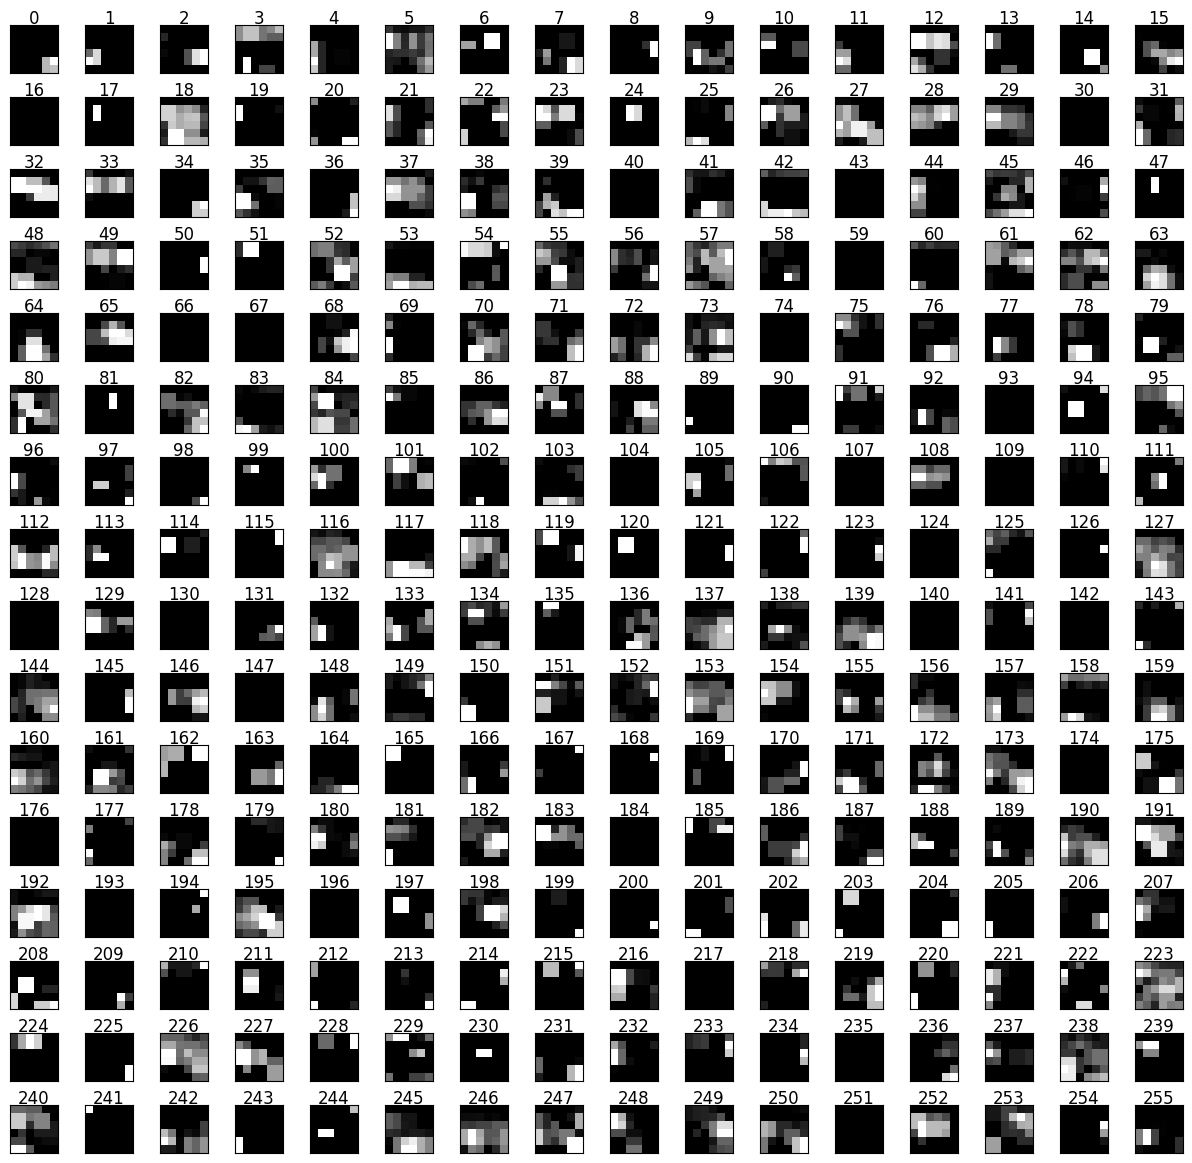

In [15]:
output_features = model_alexnet.features(batch_input).detach()
if display:
    display_pictures_grid(
        output_features.squeeze(dim=0).reshape(
            (output_features.size(1), 1, output_features.size(2), output_features.size(3))
            # .squeeze pour supprimer la partie "batch"
            # .reshape(...,1,...) pour insérer la dimension channel (à 1 car monochrome)
            ),
        per_rows=16,
        titles=range(output_features.size(1))
        )

## Comparaison des applications du modèle fourni et de sa version dérivée pour la déconvolution

Création d'un modèle

In [16]:
model_alexnet_deconv = alexnetfordeconv(weights='IMAGENET1K_V1')
model_alexnet_deconv.eval()

AlexNetForDeconv(
  (features): Sequential(
    (0): Conv2d(3, 64, kernel_size=(11, 11), stride=(4, 4), padding=(2, 2))
    (1): ReLU(inplace=True)
    (2): MaxPool2d(kernel_size=3, stride=2, padding=0, dilation=1, ceil_mode=False)
    (3): Conv2d(64, 192, kernel_size=(5, 5), stride=(1, 1), padding=(2, 2))
    (4): ReLU(inplace=True)
    (5): MaxPool2d(kernel_size=3, stride=2, padding=0, dilation=1, ceil_mode=False)
    (6): Conv2d(192, 384, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (7): ReLU(inplace=True)
    (8): Conv2d(384, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (9): ReLU(inplace=True)
    (10): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (11): ReLU(inplace=True)
    (12): MaxPool2d(kernel_size=3, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (avgpool): AdaptiveAvgPool2d(output_size=(6, 6))
  (classifier): Sequential(
    (0): Dropout(p=0.5, inplace=False)
    (1): Linear(in_features=9216, out_features=4096, bia

### Propagation sans indication d'une couche particulière (et donc la dernière par défaut), en utilisant la partie `features`.

Calcul et affichage de chaque carte obtenue dans cette couche.

Dimensions de la sortie de la déconvolution :  torch.Size([1, 256, 6, 6])


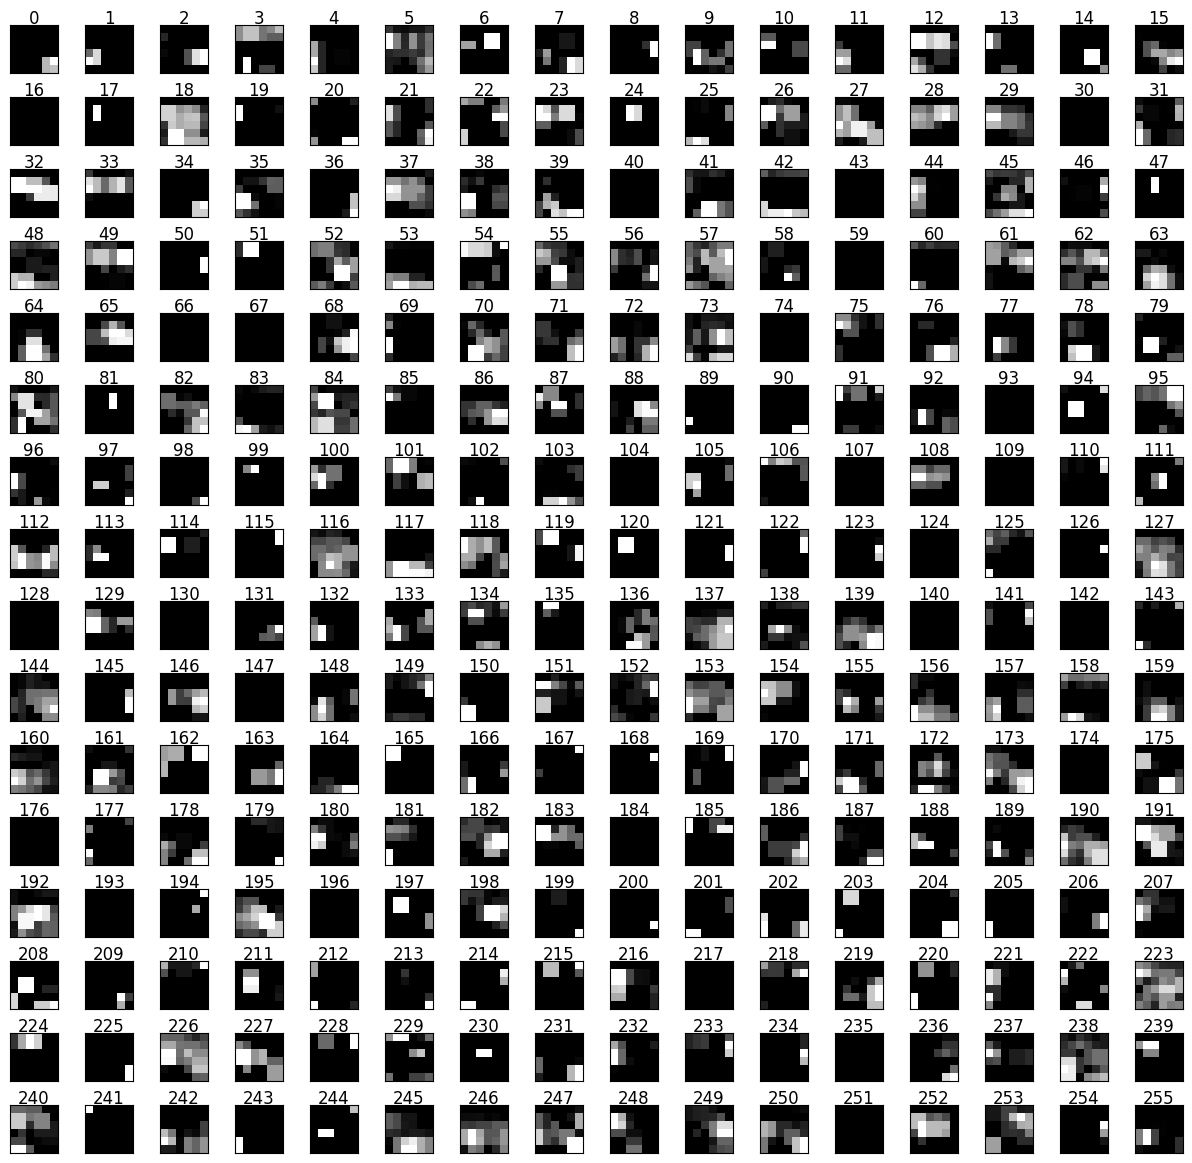

In [17]:
output_features_deconv = model_alexnet_deconv.features(batch_input).detach()
print("Dimensions de la sortie de la déconvolution : ", output_features_deconv.size())
if display:
    display_pictures_grid(
        output_features_deconv.squeeze(dim=0).reshape(
            (output_features_deconv.size(1), 1, output_features_deconv.size(2), output_features_deconv.size(3))
            # .squeeze pour supprimer la partie "batch"
            # output_features_deconv.size(1) : nombre de canaux / cartes
            # .reshape(...,1,...) pour insérer la dimension channel (à 1 car monochrome)
            ),
        per_rows=16,
        titles=range(output_features_deconv.size(1))
        )

Vérifier que la sortie de la procédure développée pour la déconvolution est identique à celle du modèle issue de la procédure de génération de PyTorch.

In [18]:
assert torch.equal(output_features, output_features_deconv), f"Problème !"
print("OK !!!")

OK !!!


### En traitant explicitement la dernière couche de la partie `features`

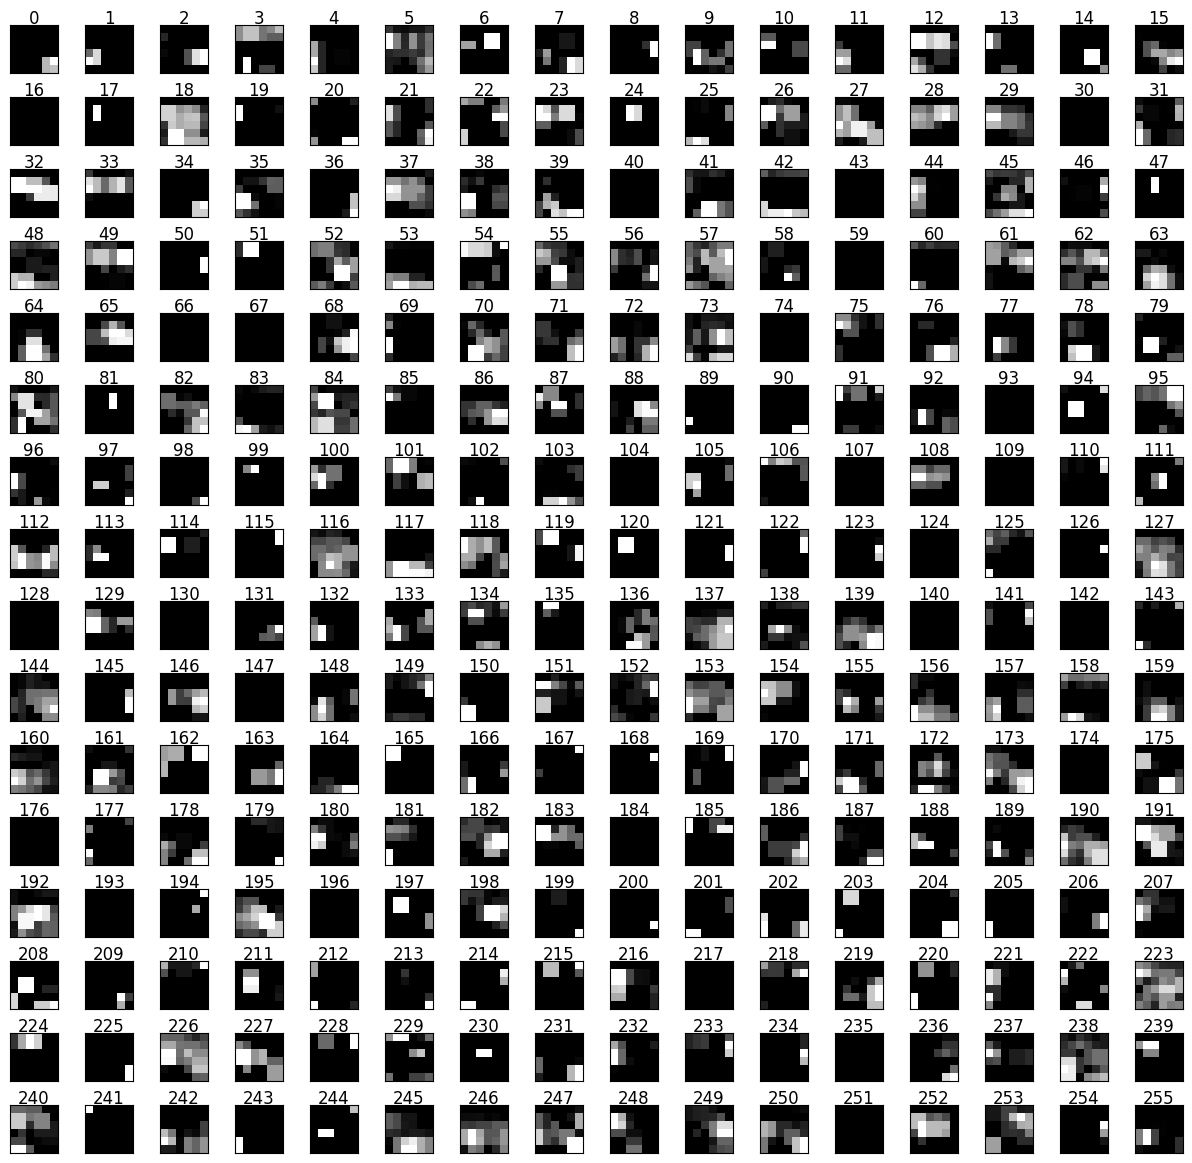

In [19]:
output_features_deconv, switches_indices = model_alexnet_deconv(batch_input, idx_layer=-1)
output_features_deconv = output_features_deconv.detach()
if display:
    display_pictures_grid(
        output_features_deconv.squeeze(dim=0).reshape(
            (output_features_deconv.size(1), 1, output_features_deconv.size(2), output_features_deconv.size(3))
            # .squeeze pour supprimer la partie "batch"
            # output_features_deconv.size(1) : nombre de canaux / cartes
            # .reshape(...,1,...) pour insérer la dimension channel (à 1 car monochrome)
            ),
        per_rows=16,
        titles=range(output_features_deconv.size(1))
        )

Vérifier que la sortie de la procédure développée pour la déconvolution est identique à celle du modèle issue de la procédure de génération de PyTorch.

In [20]:
assert torch.equal(output_features, output_features_deconv), f"Problème !"
print("OK !!!")

OK !!!


## Déconvolution

### Quelques tests préalables

Préalablement, détection du max de la sortie et de sa position dans les cartes de caractéristiques :

In [21]:
deconv_max = output_features_deconv.squeeze(dim=0).max()
print("max :", deconv_max)
print("position(s) dans le tenseur :", (output_features_deconv == deconv_max).nonzero())

max : tensor(34.2142)
position(s) dans le tenseur : tensor([[ 0, 63,  4,  2]])


Déconvolution de la sortie du dernier module de la partie `features` (c'est-à-dire sa dernière couche), càd la dernière couche.

In [22]:
print(output_features_deconv.size())
print(switches_indices[-1][1].size()) # Le dernier tuple (idx_module, indices), que les indices

torch.Size([1, 256, 6, 6])
torch.Size([1, 256, 6, 6])


Nettoyage des indices de pooling, en ne préservant que le max par batch

In [23]:
#cleaned_output, max_activation, coords = clean_feature_maps(
cleaned_output = clean_feature_maps(
    output_features_deconv,
    idx_map=False,
    pool_indices=switches_indices[-1][1],
    return_pos=True
)
print("position: ", cleaned_output[1])
cleaned_feature_maps = cleaned_output[0]
print("max :", cleaned_feature_maps.max())

position:  tensor([[ 0, 63,  4,  2]])
max : tensor(34.2142)


... ce qui correspond à la détection préalable.

Affichage des cartes nettoyées (en vérifiant la cohérence avec la position du max obtenue précédemment):

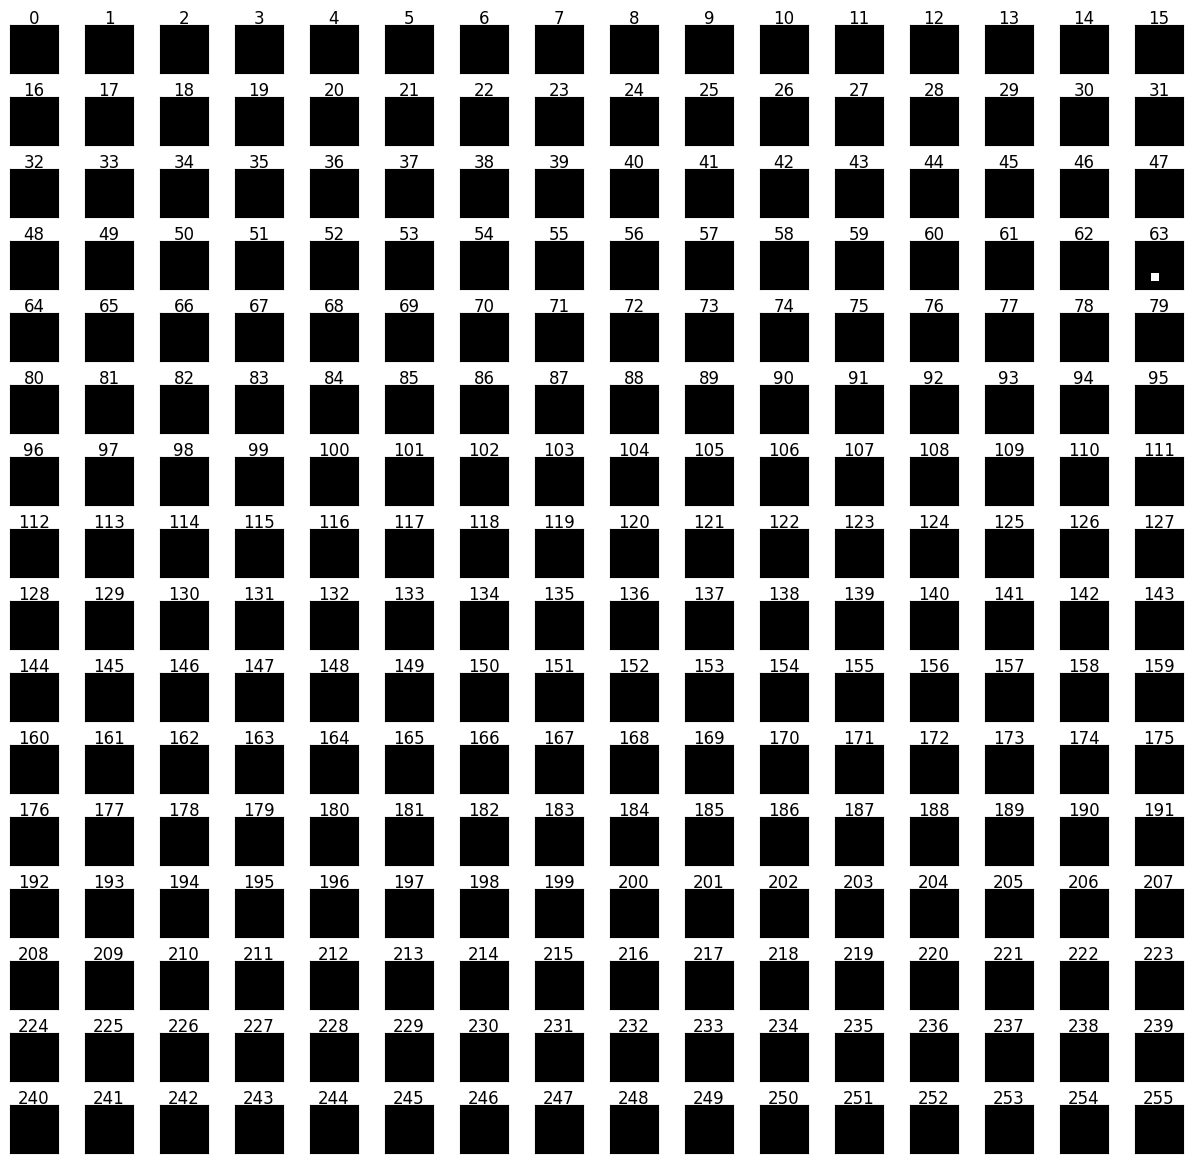

In [24]:
if display:
    display_pictures_grid(
        cleaned_feature_maps.squeeze(dim=0).reshape(
            (cleaned_feature_maps.size(1), 1, cleaned_feature_maps.size(2), cleaned_feature_maps.size(3))
            # .squeeze pour supprimer la partie "batch"
            # output_features_deconv.size(1) : nombre de canaux / cartes
            # .reshape(...,1,...) pour insérer la dimension channel (à 1 car monochrome)
            ),
        per_rows=16,
        titles=range(cleaned_feature_maps.size(1))
        )

A priori, en ne fournissant pas `idx_map`, la déconvolution repose sur l'ensemble des max de chaque canaux.

In [25]:
model_alexnet_deconv.features
print(vars(model_alexnet_deconv))
print(hasattr(model_alexnet_deconv, "features"))

{'training': False, '_parameters': {}, '_buffers': {}, '_non_persistent_buffers_set': set(), '_backward_pre_hooks': OrderedDict(), '_backward_hooks': OrderedDict(), '_is_full_backward_hook': None, '_forward_hooks': OrderedDict(), '_forward_hooks_with_kwargs': OrderedDict(), '_forward_hooks_always_called': OrderedDict(), '_forward_pre_hooks': OrderedDict(), '_forward_pre_hooks_with_kwargs': OrderedDict(), '_state_dict_hooks': OrderedDict(), '_state_dict_pre_hooks': OrderedDict(), '_load_state_dict_pre_hooks': OrderedDict(), '_load_state_dict_post_hooks': OrderedDict(), '_modules': {'features': Sequential(
  (0): Conv2d(3, 64, kernel_size=(11, 11), stride=(4, 4), padding=(2, 2))
  (1): ReLU(inplace=True)
  (2): MaxPool2d(kernel_size=3, stride=2, padding=0, dilation=1, ceil_mode=False)
  (3): Conv2d(64, 192, kernel_size=(5, 5), stride=(1, 1), padding=(2, 2))
  (4): ReLU(inplace=True)
  (5): MaxPool2d(kernel_size=3, stride=2, padding=0, dilation=1, ceil_mode=False)
  (6): Conv2d(192, 384, 

### Déconvolution

In [26]:
#output, max_coords = deconvolution(
output = deconvolution(
    model_alexnet_deconv,
    batch_input,
    idx_layer=idx_layer,
    flip_kernels=flip_kernels,
    use_bias=use_bias,
    clean_feature_map=True,
    idx_map=False,
    return_pos=True,
    verbose=True
    )

[0] forward  Conv2d(3, 64, kernel_size=(11, 11), stride=(4, 4), padding=(2, 2))
	 x.size: torch.Size([1, 64, 55, 55])
[1] forward  ReLU(inplace=True)
	 x.size: torch.Size([1, 64, 55, 55])
[2] forward  MaxPool2d(kernel_size=3, stride=2, padding=0, dilation=1, ceil_mode=False)
	 x.size: torch.Size([1, 64, 27, 27])
[3] forward  Conv2d(64, 192, kernel_size=(5, 5), stride=(1, 1), padding=(2, 2))
	 x.size: torch.Size([1, 192, 27, 27])
[4] forward  ReLU(inplace=True)
	 x.size: torch.Size([1, 192, 27, 27])
[5] forward  MaxPool2d(kernel_size=3, stride=2, padding=0, dilation=1, ceil_mode=False)
	 x.size: torch.Size([1, 192, 13, 13])
forwarded output.size torch.Size([1, 192, 13, 13]) len(switch_indices) 2
0.0 68.23957824707031
pool_indices.size torch.Size([1, 192, 13, 13])
cleaned (tensor([[[[0., 0., 0.,  ..., 0., 0., 0.],
          [0., 0., 0.,  ..., 0., 0., 0.],
          [0., 0., 0.,  ..., 0., 0., 0.],
          ...,
          [0., 0., 0.,  ..., 0., 0., 0.],
          [0., 0., 0.,  ..., 0., 0.

In [27]:
output_max_pos = output[1]
print(output_max_pos)

tensor([[  0, 141,  10,   5]])


Dimensions torch.Size([3, 224, 224]) 
Valeur min: -30.740619659423828 
Valeur max: 35.98884201049805


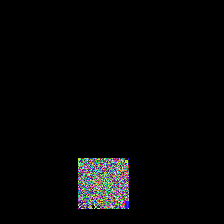

In [28]:
batch_deconvolutions = output[0]
display_image_tensor(batch_deconvolutions[0]) # First of the batch

### Calcul du champ réceptif

In [29]:
output_sizes = get_output_sizes(model_alexnet_deconv.features, input_size=batch_input.size())
output_sizes

[(55, 55),
 (55, 55),
 (27, 27),
 (27, 27),
 (27, 27),
 (13, 13),
 (13, 13),
 (13, 13),
 (13, 13),
 (13, 13),
 (13, 13),
 (13, 13),
 (6, 6)]

In [30]:
pixel_space_size = batch_input.size(-2), batch_input.size(-1)
max_pos = output_max_pos[0] # max of this batch
pos = max_pos[2:].tolist()
print(pos)
receptive_field = get_receptive_field_in_pixel_space(
    pos=pos,
    idx_layer=idx_layer,
    cnn_modules=model_alexnet_deconv.features,
    output_sizes=output_sizes,
    pixel_space_size=pixel_space_size
)
print(receptive_field)
((top, left), (bottom, right)) = receptive_field

[10, 5]
((142, 62), (208, 128))


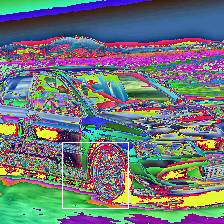

In [31]:
img_input = T.functional.to_pil_image(batch_input[0])
img_draw = ImageDraw.Draw(img_input)
img_draw.rectangle([(left, top), (right, bottom)], outline="white")
if display:
    display(img_input)

In [32]:
deconvolution = batch_deconvolutions[0].detach()

Affichage de la déconvolution et du cadre du champ réceptif

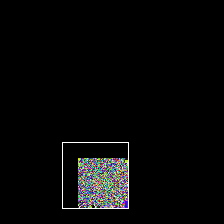

In [33]:
img_deconv = T.functional.to_pil_image(deconvolution.clone())
img_draw = ImageDraw.Draw(img_deconv)
img_draw.rectangle([(left, top), (right, bottom)], outline="white")
if display:
    display(img_deconv)

In [34]:
print(deconvolution.min(), deconvolution.max(), deconvolution.mean())

tensor(-30.7406) tensor(35.9888) tensor(-0.0008)


### Restitution de la déconvolution dans le champ réception et appréciation du résultat pour la visualisation de caractéristique.

Affichage que la partie de la déconvolution correspondant au champ réceptif

Dimensions torch.Size([3, 66, 66]) 
Valeur min: -30.740619659423828 
Valeur max: 35.98884201049805


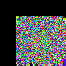

In [35]:
display_image_tensor(deconvolution[:, top:bottom, left:right])

Modification de la déconvolution pour essayer de rendre l'affichage de caractéristique plus expressif :
- application d'une ReLU

Dimensions torch.Size([3, 66, 66]) 
Valeur min: 0.0 
Valeur max: 35.98884201049805


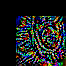

In [36]:
display_image_tensor(nn.functional.relu(deconvolution[:, top:bottom, left:right]))

- application d'une ReLU et redistribution sur $[0; 255]$ :

Dimensions torch.Size([3, 66, 66]) 
Valeur min: 0.0 
Valeur max: 255.0


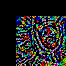

In [37]:
display_image_tensor(to_0_255(nn.functional.relu(deconvolution[:, top:bottom, left:right])))

- Simplement redistribution sur $[0; 255]$ :

Dimensions torch.Size([3, 66, 66]) 
Valeur min: 0.0 
Valeur max: 255.0


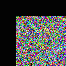

In [38]:
display_image_tensor(to_0_255(deconvolution[:, top:bottom, left:right]))

- application d'une "dénormalisation" inverse à la normalisation appliquée aux images en entrée

Dimensions torch.Size([3, 66, 66]) 
Valeur min: -6.429898262023926 
Valeur max: 8.517499923706055


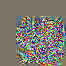

In [39]:
display_image_tensor(
    unnormalize(deconvolution[:, top:bottom, left:right], mean=imagenet_mean, std=imagenet_std)
)

- application d'une "dénormalisation" inverse à la normalisation appliquée aux images en entrée, après une ReLU :

Dimensions torch.Size([3, 66, 66]) 
Valeur min: 0.4059999883174896 
Valeur max: 8.517499923706055


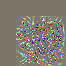

In [40]:
display_image_tensor(
    unnormalize(
        nn.functional.relu(deconvolution[:, top:bottom, left:right]),
        mean=imagenet_mean, std=imagenet_std
    )
)

Dimensions torch.Size([3, 66, 66]) 
Valeur min: 0.0 
Valeur max: 8.517499923706055


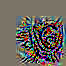

In [41]:
display_image_tensor(
    nn.functional.relu(
        unnormalize(
            deconvolution[:, top:bottom, left:right], mean=imagenet_mean, std=imagenet_std
        )
    )
)

- Utilisation d'une LocalContrastNormalization

Dimensions torch.Size([3, 66, 66]) 
Valeur min: -8.712565422058105 
Valeur max: 0.17489607632160187


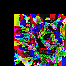

In [42]:
from utils.local_contrast_normalization import LocalContrastNormalization
local_contrast_normalization = LocalContrastNormalization(lcn_kernel_size)
display_image_tensor(local_contrast_normalization(deconvolution[:, top:bottom, left:right]))

- Utilisation d'une LocalContrastNormalization après une ReLU

Dimensions torch.Size([3, 66, 66]) 
Valeur min: 0.0 
Valeur max: 0.17842967808246613


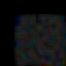

In [43]:
display_image_tensor(local_contrast_normalization(
    nn.functional.relu(deconvolution[:, top:bottom, left:right])
))

- LocalContrastNormalization puis "dénormalisation"

Dimensions torch.Size([3, 66, 66]) 
Valeur min: -1.4956146478652954 
Valeur max: 0.52288419008255


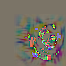

In [44]:
display_image_tensor(
    unnormalize(
        local_contrast_normalization(deconvolution[:, top:bottom, left:right]),
        mean=imagenet_mean, std=imagenet_std
    )
)

- "dénormalisation" puis LocalContrastNormalization


Dimensions torch.Size([3, 66, 66]) 
Valeur min: -1.4956145286560059 
Valeur max: 0.20000000298023224


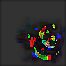

In [45]:
display_image_tensor(
    local_contrast_normalization(
        unnormalize(
            deconvolution[:, top:bottom, left:right], mean=imagenet_mean, std=imagenet_std
        )
    )
)